# 환경 설정

In [11]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [12]:
# -*- coding: utf-8 -*-
"""
scikit-learn Common Pitfalls (12.1 Inconsistent preprocessing / 12.2 Data leakage) 재현 실험 v2
데이터: Adult Census Income (약 48,842행, 수치형+범주형 혼합, 결측치 포함)

[중요 수정사항]
v1에서는 "반복 실행 시 accuracy의 분산(std)"으로 안정성을 비교했으나,
실제로 측정해보니 Wrong과 Pipeline의 분산은 거의 차이가 없었음 (분산은 주로
표본추출 자체의 무작위성에서 오기 때문에 두 방법이 같은 무작위성을 공유하면
당연히 비슷하게 나옴).

진짜 문제는 분산이 아니라 "실험 중 보고되는 성능 지표가 실제 운영 성능을
얼마나 정확히 반영하는가"이다. 그래서 이번 버전에서는:
  1. 어떤 학습에도 절대 사용하지 않는 "진짜 홀드아웃(운영 데이터)"을 처음에 한 번만 분리
  2. 매 실행(seed)마다 "실험 중 보고된 test accuracy" vs
     "그 모델을 홀드아웃에 적용했을 때의 real accuracy"를 함께 측정
  3. 두 값의 차이(gap = reported - real)를 비교
     -> Wrong은 이 gap이 크고(과대평가), Pipeline은 gap이 작음(신뢰 가능)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한국어 폰트 설정 ───────────────────────────────────────────────────
font_dirs = ['/usr/share/fonts/truetype/nanum']         # 나눔 폰트가 설치되어 있는 시스템 폴더 경로 지정
font_files = fm.findSystemFonts(fontpaths=font_dirs)    # 지정한 경로에서 폰트 파일(.ttf) 목록을 모두 찾아 리스트로 반환
for ff in font_files:
    fm.fontManager.addfont(ff)                          # 찾은 개별 폰트 파일들을 Matplotlib 폰트 매니저에 사용할 수 있도록 등록

# 시각화 전역 설정 (Wilke 스타일 + 폰트 통합) ──────────────────────────────
# Seaborn 테마 설정 (여기에 폰트를 지정해야 sns 그래프에서도 한글이 깨지지 않음)
sns.set_theme(
    style='whitegrid',                  # 배경을 하얗고 옅은 격자가 있는 스타일로 설정
    rc={
        'font.family': 'NanumBarunGothic', # 그래프의 기본 글꼴을 등록해둔 '나눔바른고딕'으로 설정 (한글 깨짐 방지)
        'axes.unicode_minus': False        # 한글 폰트 적용 시 축의 마이너스(-) 기호가 네모로 깨지는 현상 방지
    }
)

# Matplotlib 세부 스타일 설정 (흰 배경, 최소 격자, 고해상도)
plt.rcParams.update({
    'figure.dpi': 130,                  # 그래프의 해상도를 130 DPI로 설정하여 선명하게 출력
    'figure.facecolor': 'white',        # 그래프 바깥쪽 영역(Figure)의 배경색을 흰색으로 설정
    'axes.facecolor': '#FAFAFA',        # 그래프 안쪽 영역(Axes)의 배경색을 아주 옅은 회색으로 설정
    'axes.spines.top': False,           # 그래프의 위쪽 테두리 선을 숨김 (깔끔한 시각화를 위해)
    'axes.spines.right': False,         # 그래프의 오른쪽 테두리 선을 숨김
    'axes.grid': True,                  # 그래프 내부에 격자선을 표시하도록 설정
    'grid.alpha': 0.3,                  # 격자선의 투명도를 0.3으로 설정 (연하게 표시)
    'grid.linestyle': '--',             # 격자선의 모양을 점선(dash)으로 설정
    'axes.titlesize': 13,               # 그래프 제목(Title)의 글씨 크기를 13으로 설정
    'axes.labelsize': 11,               # x축, y축 이름(Label)의 글씨 크기를 11로 설정
    'xtick.labelsize': 9,               # x축 눈금 숫자들의 글씨 크기를 9로 설정
    'ytick.labelsize': 9,               # y축 눈금 숫자들의 글씨 크기를 9로 설정
    'legend.fontsize': 9,               # 범례(Legend)의 글씨 크기를 9로 설정
})

# 데이터 가져오기

## 1. 개요

| 항목 | 내용 |
|---|---|
| 파일명 | adult.csv |
| 데이터셋명 | Adult Census Income (미국 인구조사 소득 데이터) |
| 출처 | UCI Machine Learning Repository (1994년 미국 census bureau 데이터 기반), GitHub 미러(jbrownlee/Datasets)에서 다운로드 |
| 전체 행 수 | 48,842행 |
| 전체 컬럼 수 | 15개 (피처 14 + 타겟 1) |
| 헤더 | 없음 (원본 파일에 컬럼명 없음, 별도 지정 필요) |
| 결측치 표기 | `?` (읽어들인 후 `NaN`으로 변환 필요) |
| 인코딩 | UTF-8 |
| 구분자 | 콤마(`,`) |

## 2. 컬럼 정의서

| 컬럼명 | 설명 | 타입 | 결측치 | 범위/카테고리 |
|---|---|---|---|---|
| `age` | 나이 | 수치형(int) | 없음 | 17 ~ 90 (평균 38.6) |
| `workclass` | 고용 형태 | 범주형 | 2,799건 (5.7%) | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked (8종) |
| `fnlwgt` | Final Weight — 인구조사 표본이 대표하는 인구 수 가중치 (모델링에는 보통 제외 권장) | 수치형(int) | 없음 | 12,285 ~ 1,490,400 |
| `education` | 최종 학력 | 범주형 | 없음 | Preschool, 1st-4th, 5th-6th, 7th-8th, 9th, 10th, 11th, 12th, HS-grad, Some-college, Assoc-voc, Assoc-acdm, Bachelors, Masters, Prof-school, Doctorate (16종) |
| `education_num` | 학력을 숫자로 환산한 값 (education과 1:1 대응, 서수형) | 수치형(int) | 없음 | 1 ~ 16 |
| `marital_status` | 결혼 상태 | 범주형 | 없음 | Never-married, Married-civ-spouse, Divorced, Married-spouse-absent, Separated, Married-AF-spouse, Widowed (7종) |
| `occupation` | 직업 | 범주형 | 2,809건 (5.8%) | Adm-clerical, Exec-managerial, Prof-specialty, Sales, Tech-support, Craft-repair, Machine-op-inspct, Transport-moving, Handlers-cleaners, Farming-fishing, Other-service, Priv-house-serv, Protective-serv, Armed-Forces (14종) |
| `relationship` | 가구 내 관계 | 범주형 | 없음 | Husband, Wife, Own-child, Not-in-family, Other-relative, Unmarried (6종) |
| `race` | 인종 | 범주형 | 없음 | White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other (5종) |
| `sex` | 성별 | 범주형 | 없음 | Male, Female (2종) |
| `capital_gain` | 자본 이득 | 수치형(int) | 없음 | 0 ~ 99,999 (75%가 0, 왜도 매우 큼) |
| `capital_loss` | 자본 손실 | 수치형(int) | 없음 | 0 ~ 4,356 (75%가 0, 왜도 매우 큼) |
| `hours_per_week` | 주당 근무시간 | 수치형(int) | 없음 | 1 ~ 99 (평균 40.4) |
| `native_country` | 출신 국가 | 범주형 | 857건 (1.8%) | United-States 외 40개국 (미국 비중 89.7%로 극심한 불균형) |
| `income` | **타겟 변수**: 연소득 구간 | 범주형(이진) | 없음 | `<=50K` (37,155건, 76.1%), `>50K` (11,687건, 23.9%) |

## 3. 결측치 요약

| 컬럼 | 결측 건수 | 비율 |
|---|---|---|
| `occupation` | 2,809 | 5.75% |
| `workclass` | 2,799 | 5.73% |
| `native_country` | 857 | 1.75% |

- 세 컬럼 모두 결측 위치가 대체로 겹침 (`workclass`가 결측이면 `occupation`도 대부분 결측).
- 원본에는 `?`로 표기되어 있어 로드 후 `df.replace("?", np.nan)` 처리 필요.

## 4. 데이터 다루기 유의사항

- **`fnlwgt`**: 표본 가중치이므로 예측 피처로 넣으면 노이즈만 추가될 수 있어 통상 제외.
- **`education` vs `education_num`**: 같은 정보의 문자/숫자 버전이므로 인코딩 시 하나만 사용 권장(중복 시 다중공선성).
- **`capital_gain`/`capital_loss`**: 0이 압도적으로 많은 zero-inflated 분포 → 스케일링 전 로그 변환 등을 고려할 수 있음.
- **`native_country`**: United-States가 90% 가까이 차지 → 원핫인코딩 시 희소 카테고리 다수 발생, `handle_unknown="ignore"` 필수.
- **`income`(타겟)**: 클래스 불균형(76:24) → accuracy 외에 precision/recall, F1 등 추가 지표 권장.
- 본 파일은 본래 train/test가 나뉘어 배포되는 데이터셋을 하나로 합친 버전이라 `income` 값에 마침표(`.`)가 붙은 행이 섞여 있을 수 있으니, 실제 사용 전 `df["income"].str.strip().str.rstrip(".")` 형태로 정리 권장.

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# =========================================================
# 0. 데이터 로드 (Adult Census Income)
# =========================================================

# 원본 데이터(adult.csv)에는 컬럼명(헤더)이 포함되어 있지 않으므로,
# 데이터 정의서에 맞춰 15개의 컬럼명을 순서대로 리스트로 정의해 줍니다.
COLS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income",
]

# 구글 드라이브 내 데이터셋이 위치한 경로를 지정합니다.
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/adult.csv'

# pd.read_csv를 사용해 데이터를 불러옵니다.
# header=None: 파일의 첫 번째 줄을 컬럼명으로 인식하지 않도록 설정
# names=COLS: 위에서 직접 정의한 컬럼명 리스트를 덮어씌움
df = pd.read_csv(DATA_PATH, header=None, names=COLS)

# 데이터 소개에 명시된 대로 결측치가 '?' 기호로 들어가 있으므로,
# 이를 판다스가 인식할 수 있는 공식적인 빈칸(np.nan)으로 모두 교체합니다.
# 데이터 정렬을 위해 인덱스도 깔끔하게 초기화(reset_index) 합니다.
df = df.replace("?", np.nan).reset_index(drop=True)

# 모델링에 사용할 수치형(숫자) 변수와 범주형(문자/카테고리) 변수들을 각각 리스트로 분류합니다.
# (향후 ColumnTransformer에서 파이프라인을 분리 적용하기 위함입니다.)
NUM_COLS = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
CAT_COLS = ["workclass", "education", "marital_status", "occupation",
            "relationship", "race", "sex", "native_country"]

# 모델 학습에 사용할 독립변수(X) 전체 데이터를 생성합니다.
X_full = df[NUM_COLS + CAT_COLS]

# 모델이 예측해야 할 타겟 변수(y)를 생성합니다.
# 원본 데이터의 income 값에 공백이나 마침표가 섞여 있을 수 있으므로 .str.strip()으로 양옆 공백을 제거합니다.
# 소득이 5만 달러 초과(">50K")이면 True, 아니면 False로 반환한 뒤,
# .astype(int)를 통해 최종적으로 머신러닝이 이해할 수 있는 1과 0으로 변환합니다.
y_full = (df["income"].str.strip() == ">50K").astype(int)

# =========================================================
# 진짜 홀드아웃(Holdout) 데이터 분리
# =========================================================
# 이 단계에서 떼어놓은 데이터는 향후 운영(실제 배포) 환경의 데이터 역할을 합니다.
# 어떠한 전처리(imputer, scaler 등)를 학습시킬 때도 절대 사용하지 않아야 데이터 누수(Leakage)를 막을 수 있습니다.

# 전체 데이터 중 20%(test_size=0.2)를 평가 전용 홀드아웃 데이터로 분리합니다.
# stratify=y_full: 소득 불균형(76:24) 비율이 분할된 데이터에도 동일하게 유지되도록 비율을 맞춰서 쪼갭니다.
DEV_idx, HOLDOUT_idx = train_test_split(
    X_full.index, test_size=0.2, random_state=999, stratify=y_full
)

# 인덱스를 기반으로 실제 데이터를 분리하여 저장하고, 인덱스를 0부터 다시 정리(reset_index)합니다.
# X_hold, y_hold: 최종 평가 전까지 절대 열어보지 않을 모의고사용 데이터
X_hold = X_full.loc[HOLDOUT_idx].reset_index(drop=True)
y_hold = y_full.loc[HOLDOUT_idx].reset_index(drop=True)

# X_dev, y_dev: 교차 검증 및 모델 학습(Training)에 자유롭게 사용할 개발용 데이터
X_dev = X_full.loc[DEV_idx].reset_index(drop=True)
y_dev = y_full.loc[DEV_idx].reset_index(drop=True)

# 분할이 의도한 비율대로 잘 되었는지 데이터의 행(row) 개수를 출력하여 확인합니다.
print(f"전체: {X_full.shape}, 개발용(DEV): {X_dev.shape}, 진짜 홀드아웃: {X_hold.shape}")

전체: (48842, 14), 개발용(DEV): (39073, 14), 진짜 홀드아웃: (9769, 14)


# 테스트

## 코드 전체 흐름 및 핵심 요약

이 코드는 머신러닝 워크플로우에서 데이터 누수(Data Leakage)가 모델 평가 지표에 미치는 심각한 악영향을 실험을 통해 증명하고, 이를 완벽하게 차단할 수 있는 파이프라인(Pipeline)의 중요성을 강조하는 시뮬레이션입니다.

### 1. 실험의 배경: 데이터 누수(Data Leakage)란?

머신러닝 모델이 평가용 데이터(Test/Holdout)의 정보를 학습 과정(Train)에서 미리 알게 되는 현상입니다. 이 경우, 모델의 평가 점수는 비정상적으로 높게 측정되지만, 한 번도 보지 못한 실제 운영 환경의 데이터가 주어졌을 때는 성능이 급격히 하락하게 됩니다.

### 2. 두 가지 워크플로우 비교

**안티 패턴 (`run_wrong`)**

- **오류 1:** 데이터를 훈련용과 테스트용으로 분리하기 **전**에 오버샘플링을 진행합니다. 이로 인해 동일하게 복제된 데이터가 Train과 Test 세트 양쪽에 들어가, 모델이 정답을 미리 외우는 상황이 발생합니다.
- **오류 2:** 데이터를 분리하기 **전**에 결측치 채우기(Imputer)와 스케일링(Scaler)을 전체 데이터 기준으로 학습(fit)시킵니다. 테스트 데이터의 통계적 특징(평균, 중앙값 등)이 훈련 과정에 유입됩니다.

**베스트 프랙티스 (`run_pipeline`)**

- **개선 1:** 모든 전처리나 샘플링 이전에 순수한 원본 데이터를 Train과 Test로 **가장 먼저 분리**합니다.
- **개선 2:** 오버샘플링은 오직 Train 데이터에만 적용하여 Test 데이터의 무결성을 유지합니다.
- **개선 3:** Scikit-learn의 **Pipeline**을 사용하여 `fit(학습)` 과정은 오직 Train 데이터에만 강제로 적용되도록 설계합니다. Test 데이터에는 `transform(변환)`만 수행되므로 누수를 원천 차단합니다.

### 3. 실험 방법 및 결과

위의 두 가지 모델링 방식을 각각 20회 반복 실험합니다. 그런 다음, 모델이 내부적으로 자체 평가한 "보고된 테스트 점수"와 모델이 한 번도 보지 못한 **"진짜 홀드아웃(운영) 점수"** 간의 격차(Gap)를 측정합니다.

- **잘못된 설계(Wrong)의 결과:** 보고된 성능과 실제 성능의 차이가 매우 큽니다. 즉, 실무자에게 "이 모델은 성능이 좋습니다"라고 거짓말을 하는 신뢰할 수 없는 평가 지표가 만들어집니다.
- **파이프라인 설계(Pipeline)의 결과:** 보고된 성능과 실제 성능이 거의 동일합니다. 평가 지표가 정직하게 측정됩니다.
- **최종 시사점:** 데이터 누수의 가장 무서운 점은 모델 자체가 고장 나는 것이 아니라, **평가 지표를 믿을 수 없게 만든다**는 점입니다. 실무에서는 배포 후 진짜 성능을 정확히 예측하는 것이 중요하므로 파이프라인(Pipeline) 사용이 필수적입니다.


=== 결과 비교 (20회 반복) ===
Wrong    : 보고된 test acc=0.8223 | 실제 홀드아웃 acc=0.8003 | 과대평가 gap=+0.0220 (std=0.0146)
Pipeline : 보고된 test acc=0.8068 | 실제 홀드아웃 acc=0.7995 | 과대평가 gap=+0.0073 (std=0.0153)


/tmp/ipykernel_2399/760304628.py:178: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_2399/760304628.py:179: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig("pipeline_reliability_comparison.png", dpi=150)



그래프 저장 완료: pipeline_reliability_comparison.png

=== 결론 ===
- 반복 실행 시 accuracy의 '분산'만 보면 Wrong과 Pipeline은 거의 차이가 없었음
  (분산은 주로 어떤 데이터가 샘플링되는지에서 오며, 두 방법이 이를 공유하기 때문)
- 진짜 차이는 '보고된 성능을 얼마나 믿을 수 있는가'에 있음
  Wrong은 평균 +0.0220p, Pipeline은 평균 +0.0073p만큼
  실제 운영 성능보다 부풀려서 보고함
- Data Leakage는 '모델이 흔들린다'기보다 '평가 지표 자체를 믿을 수 없게 만든다'는
  방식으로 안정성을 해침 -> 실무에서는 진짜 성능을 알 수 없는 채로 배포하게 되는 위험
- Pipeline은 train에만 fit을 강제해 보고된 점수와 실제 운영 성능의 괴리를 최소화함


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


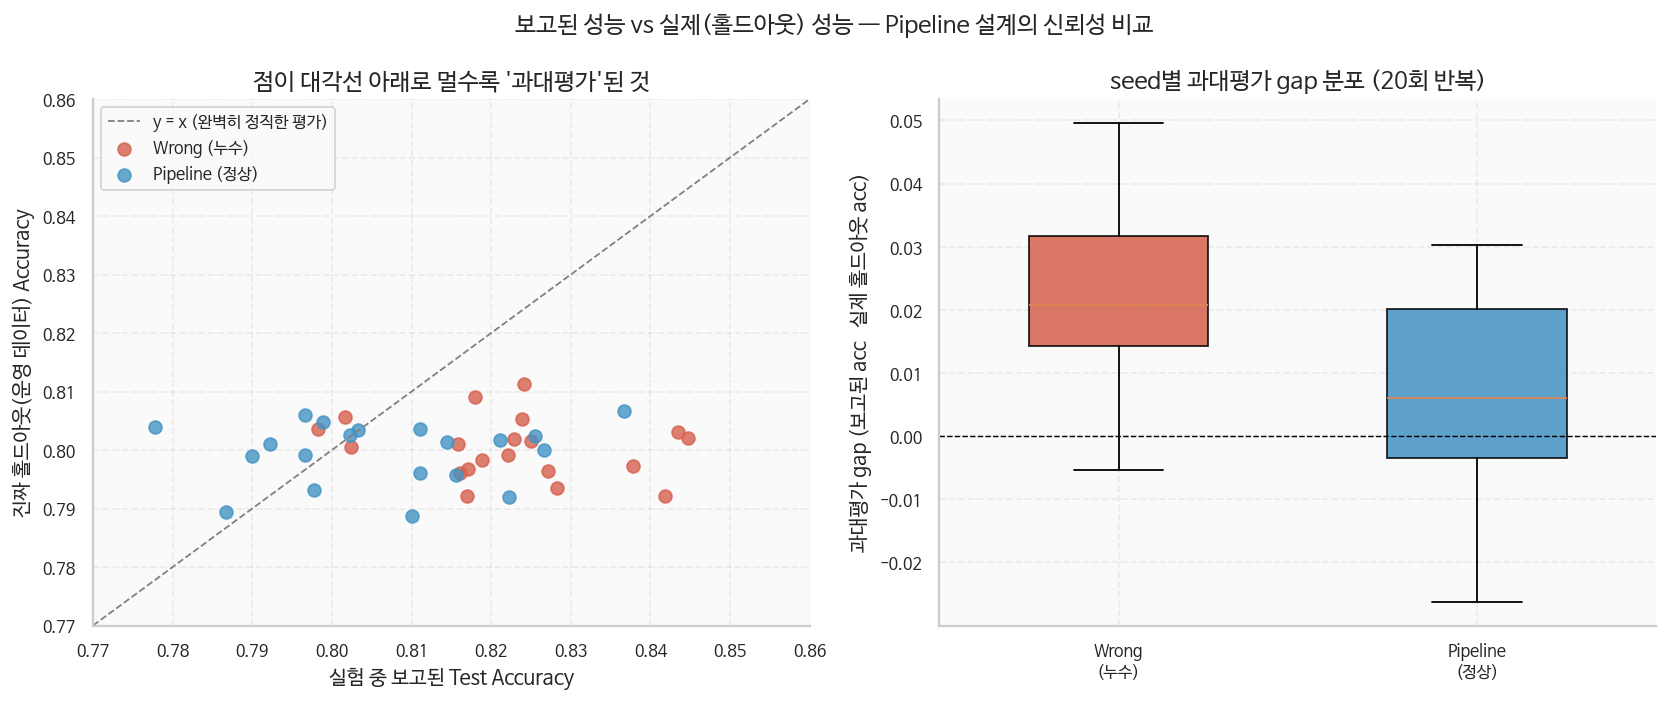

In [18]:
N_RUNS = 20        # 실험을 반복할 횟수
N_SAMPLE = 3000    # 매 실험마다 DEV 데이터에서 무작위로 추출할 샘플의 크기 (연산 속도를 위해 제한)

def oversample(X, y, seed):
    """
    소수 클래스(y=1)의 데이터를 다수 클래스(y=0)의 개수만큼
    단순 복원 추출(Random Oversampling)하여 불균형을 맞추는 함수입니다.
    """
    rng = np.random.RandomState(seed)
    minority_idx = y[y == 1].index
    # 다수 클래스와 소수 클래스의 개수 차이 계산
    n_dup = (y == 0).sum() - (y == 1).sum()

    # 소수 클래스 인덱스 중에서 부족한 개수만큼 무작위 복원 추출(replace=True)
    dup_idx = rng.choice(minority_idx, size=max(n_dup, 0), replace=True)

    # 원본 데이터에 복제된 데이터를 이어 붙임(concat)
    X_dup = pd.concat([X, X.loc[dup_idx]], ignore_index=True)
    y_dup = pd.concat([y, y.loc[dup_idx]], ignore_index=True)

    return X_dup, y_dup

# =========================================================
# 1. 잘못된 코드 (Wrong / Anti-pattern)
# =========================================================
def run_wrong(seed):
    # 1) DEV 세트에서 N_SAMPLE개 추출
    idx = X_dev.sample(n=N_SAMPLE, random_state=seed).index
    Xs, ys = X_dev.loc[idx].reset_index(drop=True), y_dev.loc[idx].reset_index(drop=True)

    # [치명적 오류 1] Train/Test를 나누기 '이전'에 오버샘플링을 수행함!
    # 이대로 split하면 동일하게 복제된 데이터가 Train과 Test 양쪽에 모두 들어가게 되어,
    # 모델이 테스트 데이터의 정답을 이미 외우고 있는 상태(Data Leakage)가 됩니다.
    Xo, yo = oversample(Xs, ys, seed)

    # [치명적 오류 2] 전처리기를 Train/Test 분리 '이전' 전체 데이터 기준으로 학습(fit)함!
    # Imputer(중앙값)와 Scaler(평균, 분산)가 테스트 데이터의 정보를 훔쳐보게 됩니다.
    num_imp = SimpleImputer(strategy="median").fit(Xo[NUM_COLS])
    Xn = pd.DataFrame(num_imp.transform(Xo[NUM_COLS]), columns=NUM_COLS)

    scaler = StandardScaler().fit(Xn)
    Xn = pd.DataFrame(scaler.transform(Xn), columns=NUM_COLS)

    cat_imp = SimpleImputer(strategy="most_frequent").fit(Xo[CAT_COLS])
    Xc = pd.DataFrame(cat_imp.transform(Xo[CAT_COLS]), columns=CAT_COLS)

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(Xc)
    Xc_enc = encoder.transform(Xc)
    X_all = np.hstack([Xn.values, Xc_enc])

    # 이미 오염된 데이터를 뒤늦게 Train과 Test로 분리
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, yo, test_size=0.3, random_state=seed, stratify=yo
    )

    # 모델 학습 및 내부 테스트 평가
    clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    reported = accuracy_score(y_test, clf.predict(X_test)) # 테스트 데이터가 누수되어 점수가 부풀려짐

    # 같은(이미 오염된) 전처리기를 "진짜 홀드아웃(운영 데이터)"에 적용해 실제 성능 측정
    Hn = pd.DataFrame(num_imp.transform(X_hold[NUM_COLS]), columns=NUM_COLS)
    Hn = pd.DataFrame(scaler.transform(Hn), columns=NUM_COLS)
    Hc = pd.DataFrame(cat_imp.transform(X_hold[CAT_COLS]), columns=CAT_COLS)
    Hc_enc = encoder.transform(Hc)
    H_all = np.hstack([Hn.values, Hc_enc])

    real = accuracy_score(y_hold, clf.predict(H_all)) # 데이터 누수가 없는 진짜 성능

    return reported, real

# =========================================================
# 2. Pipeline 코드 (Right / Best practice)
# =========================================================
def run_pipeline(seed):
    # 1) DEV 세트에서 N_SAMPLE개 추출
    idx = X_dev.sample(n=N_SAMPLE, random_state=seed).index
    Xs, ys = X_dev.loc[idx].reset_index(drop=True), y_dev.loc[idx].reset_index(drop=True)

    # [올바른 방법 1] 오버샘플링이나 전처리 전에 순수 원본 데이터를 Train/Test로 완벽히 먼저 분리!
    X_train, X_test, y_train, y_test = train_test_split(
        Xs, ys, test_size=0.3, random_state=seed, stratify=ys
    )

    # [올바른 방법 2] 오버샘플링은 오직 'Train' 데이터에만 적용! (Test 데이터는 원본 비율 유지)
    X_train_o, y_train_o = oversample(
        X_train.reset_index(drop=True), y_train.reset_index(drop=True), seed
    )

    # [올바른 방법 3] Pipeline을 사용하여 모델 학습 시 Test 데이터의 정보 누수를 원천 차단
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, NUM_COLS),
        ("cat", categorical_pipe, CAT_COLS),
    ])
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ])

    # Pipeline은 X_train_o 데이터에만 fit을 수행하므로 누수가 발생하지 않음
    model.fit(X_train_o, y_train_o)

    # 예측 시에는 자동으로 학습된 기준(Train)에 따라 Test와 Holdout 데이터를 변환(transform)함
    reported = accuracy_score(y_test, model.predict(X_test))
    real = accuracy_score(y_hold, model.predict(X_hold))   # 진짜 홀드아웃 성능

    return reported, real

# =========================================================
# 3. 반복 실행 및 성능 비교
# =========================================================
wrong_reported, wrong_real = [], []
pipe_reported, pipe_real = [], []

# N_RUNS(20회) 만큼 두 가지 방법을 반복 실험하여 결과값을 수집
for seed in range(N_RUNS):
    r, h = run_wrong(seed)
    wrong_reported.append(r); wrong_real.append(h)

    r, h = run_pipeline(seed)
    pipe_reported.append(r); pipe_real.append(h)

# 리스트를 Numpy 배열로 변환하여 벡터 연산(차이 계산) 수행
wrong_reported, wrong_real = np.array(wrong_reported), np.array(wrong_real)
pipe_reported, pipe_real = np.array(pipe_reported), np.array(pipe_real)

# 과대평가 정도 계산: 보고된(내부 테스트) 점수 - 실제(운영 데이터) 점수
wrong_gap = wrong_reported - wrong_real
pipe_gap = pipe_reported - pipe_real

print("\n=== 결과 비교 (20회 반복) ===")
print(f"Wrong    : 보고된 test acc={wrong_reported.mean():.4f} | 실제 홀드아웃 acc={wrong_real.mean():.4f} "
      f"| 과대평가 gap={wrong_gap.mean():+.4f} (std={wrong_gap.std():.4f})")
print(f"Pipeline : 보고된 test acc={pipe_reported.mean():.4f} | 실제 홀드아웃 acc={pipe_real.mean():.4f} "
      f"| 과대평가 gap={pipe_gap.mean():+.4f} (std={pipe_gap.std():.4f})")

# =========================================================
# 4. 시각화 (fig, ax)
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("보고된 성능 vs 실제(홀드아웃) 성능 — Pipeline 설계의 신뢰성 비교", fontsize=13)

# (좌) 산점도: 보고된 acc vs 진짜 홀드아웃 acc
lims = [0.77, 0.86]
ax[0].plot(lims, lims, "--", color="gray", linewidth=1, label="y = x (완벽히 정직한 평가)") # 기준선 (보고된 점수 = 실제 점수)
ax[0].scatter(wrong_reported, wrong_real, color="#d6604d", label="Wrong (누수)", alpha=0.8, s=50)
ax[0].scatter(pipe_reported, pipe_real, color="#4393c3", label="Pipeline (정상)", alpha=0.8, s=50)
ax[0].set_xlabel("실험 중 보고된 Test Accuracy")
ax[0].set_ylabel("진짜 홀드아웃(운영 데이터) Accuracy")
ax[0].set_title("점이 대각선 아래로 멀수록 '과대평가'된 것")
ax[0].set_xlim(lims); ax[0].set_ylim(lims)
ax[0].legend(loc="upper left", fontsize=9)
ax[0].grid(alpha=0.3)

# (우) Boxplot: 방법별 seed별 gap 분포 비교 (얼마나 성능을 부풀렸는지)
bp = ax[1].boxplot(
    [wrong_gap, pipe_gap],
    tick_labels=["Wrong\n(누수)", "Pipeline\n(정상)"],
    widths=0.5,
    patch_artist=True,
)
bp["boxes"][0].set_facecolor("#d6604d")
bp["boxes"][1].set_facecolor("#4393c3")
for box in bp["boxes"]:
    box.set_alpha(0.85)
ax[1].axhline(0, color="black", linewidth=0.8, linestyle="--") # gap = 0 (정직함) 기준선
ax[1].set_ylabel("과대평가 gap (보고된 acc − 실제 홀드아웃 acc)")
ax[1].set_title("seed별 과대평가 gap 분포 (20회 반복)")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("pipeline_reliability_comparison.png", dpi=150)
print("\n그래프 저장 완료: pipeline_reliability_comparison.png")

# =========================================================
# 5. 결론 출력
# =========================================================
print("\n=== 결론 ===")
print(f"- 반복 실행 시 accuracy의 '분산'만 보면 Wrong과 Pipeline은 거의 차이가 없었음")
print(f"  (분산은 주로 어떤 데이터가 샘플링되는지에서 오며, 두 방법이 이를 공유하기 때문)")
print(f"- 진짜 차이는 '보고된 성능을 얼마나 믿을 수 있는가'에 있음")
print(f"  Wrong은 평균 {wrong_gap.mean():+.4f}p, Pipeline은 평균 {pipe_gap.mean():+.4f}p만큼")
print(f"  실제 운영 성능보다 부풀려서 보고함")
print(f"- Data Leakage는 '모델이 흔들린다'기보다 '평가 지표 자체를 믿을 수 없게 만든다'는")
print(f"  방식으로 안정성을 해침 -> 실무에서는 진짜 성능을 알 수 없는 채로 배포하게 되는 위험")
print(f"- Pipeline은 train에만 fit을 강제해 보고된 점수와 실제 운영 성능의 괴리를 최소화함")

# scikit-learn 공식 문서 "12. Common Pitfalls and Recommended Practices" 쉽게 풀어보기

- 이 문서는 "요리할 때 자주 하는 실수 모음집" 같은 것.
- scikit-learn 문서도 머신러닝 모델을 만들 때 자주 하는 실수와 잘못된 습관을 보여주고, 그 옆에 올바른 방법을 알려줌

---

##  12.1. 전처리를 일관되게 안 하는 실수 (Inconsistent Preprocessing)

**비유**: 시험공부할 때는 "cm" 단위로 외웠는데, 실제 시험 문제는 "inch"로 나온 것과 같음. 공부한 방식과 시험 방식이 다르면 아무리 열심히 공부해도 점수가 잘 안 나옴.

- scikit-learn은 데이터를 깨끗이 하거나(전처리), 줄이거나, 늘리는 다양한 변환 도구들을 제공
- 모델을 훈련시킬 때 이런 변환을 썼다면, 나중에 테스트 데이터나 실제 서비스 데이터에도 반드시 똑같은 변환을 적용해야 함
- **잘못된 예시**: 훈련 데이터는 스케일(단위)을 맞춰줬는데, 테스트 데이터는 그대로 둠 → 예측 성능이 뚝 떨어짐.
- **올바른 예시**: 훈련 데이터에 썼던 것과 **똑같은 스케일러**를 테스트 데이터에도 적용 → 성능이 정상으로 돌아옴.
- 더 좋은 방법: `Pipeline`이라는 "레시피 박스"를 사용하면 전처리와 모델을 하나로 묶어서, 변환하는 단계를 깜빡 잊어버릴 가능성 자체를 줄여줍니다.

---

## 12.2. 데이터 누수 (Data Leakage)

**비유** : 시험 보기 전에 몰래 답안지를 훔쳐본 것과 같음.

- 데이터 누수란, 예측하는 시점에는 실제로 알 수 없는 정보를 모델을 만들 때 몰래 써버리는 것을 말합니다.
- 이렇게 되면 지나치게 낙관적인(실제보다 부풀려진) 성능 점수가 나오고, 나중에 진짜 새로운 데이터(예: 실제 서비스)에서는 성능이 오히려 나빠집니다.
- **규칙**: 테스트 데이터에는 절대로 `fit`(학습)을 걸면 안 됩니다. 시험지(test)는 "채점용"이지 "공부용"이 아님.
- 예를 들어 평균값으로 데이터를 나누는 전처리를 한다면, 그 평균은 훈련 데이터만으로 계산해야지, 전체 데이터로 계산하면 안 됨. (마치 반 전체 시험 평균을 미리 알고 내 점수를 맞추는 것과 같아요.)

### 데이터 누수를 막는 방법
- 전처리를 하기 전에, 데이터를 훈련용/테스트용으로 먼저 나누세요.
- `fit`이나 `fit_transform`은 테스트 데이터에 절대 쓰지 마세요. 전체 데이터로 `fit`을 하면 점수가 지나치게 좋게 나옵니다.
- 대신 `transform`은 훈련·테스트 둘 다에 적용해야 합니다 — 훈련에는 `fit_transform`, 테스트에는 `transform`만 쓰면 됩니다.
- `Pipeline`을 쓰면 어떤 데이터에 어떤 메서드를 써야 하는지 자동으로 올바르게 처리해주기 때문에 데이터 누수를 막는 최고의 방법입니다.

### 실제 실험 예시 (완전 무작위 데이터로 확인)
- 실제로는 **아무 의미 없는 랜덤 숫자**로 만든 데이터인데도:
  - **잘못된 방법** (전체 데이터로 먼저 중요한 특징을 골라낸 후 나누기): 정확도 **0.76**이 나옴 → 원래는 랜덤이라 0.5가 나와야 정상인데 부풀려짐!
  - **올바른 방법** (먼저 나누고, 훈련 데이터로만 특징 선택): 정확도 **0.5** → 이게 진짜 정직한 결과예요.
- 마치 "동전 던지기 결과를 미리 다 보고 나서 이번엔 앞면이 잘 나오는 동전만 골랐다"고 우기는 것과 같아요 — 당연히 잘 맞는 것처럼 보이지만 사실 속임수인 거죠.

---

## 12.3. 무작위성(randomness) 다루기 (Controlling Randomness)

**비유**: 주사위를 던질 때 "항상 같은 방식으로 던지는 로봇 팔"을 쓰는지, 아니면 "매번 다르게 던지는 사람"이 던지는지에 따라 결과 해석이 완전히 달라짐.

- random forest 같은 일부 모델이나 KFold 같은 교차검증 도구는 태생적으로 무작위성을 가지고 있고, 이는 `random_state`라는 파라미터로 조절합니다.
- **정수(예: 42)를 넣으면** → `fit`이나 `split`을 여러 번 불러도 항상 똑같은 결과가 나옵니다. (같은 방식으로 던지는 로봇 팔)
- **`None`이나 `RandomState` 객체를 넣으면** → 부를 때마다 다른 결과가 나오고, 모든 가능한 무작위성을 다양하게 탐색하게 됩니다. (매번 다르게 던지는 사람)

### 왜 이게 중요할까?
- 모델(estimator)에 정수를 넣으면 교차검증의 모든 fold(조각)에서 같은 무작위 패턴이 반복되지만, `RandomState` 객체를 넣으면 fold마다 다른 무작위성을 갖게 됩니다.
- 비유하자면: 정수를 넣는 건 "모든 반에서 항상 같은 자리 배치로 시험을 보는 것", 객체를 넣는 건 "반마다 자리를 무작위로 다르게 배치하는 것" — 후자가 "이 학생이 진짜 실력이 있는지" 더 공정하게 확인할 수 있어요.
- 그래서 모델의 안정적인 교차검증 결과를 얻으려면 모델 쪽에는 `RandomState` 객체(또는 None)를 쓰는 게 더 안전합니다.
- 반대로 교차검증을 쪼개는 도구(splitter)에는 정수를 넣는 게 더 안전합니다 — 그래야 여러 모델을 "같은 시험지"로 공정하게 비교할 수 있거든요.
- 실행할 때마다 똑같은 결과를 재현하고 싶다면, `random_state=None`을 쓰는 부분을 모두 없애고 고정된 값을 넣어줘야 합니다.

---

## 한 줄 요약

| 함정 | 비유 | 해결책 |
|---|---|---|
| 전처리 불일치 | cm로 공부하고 inch로 시험 봄 | 훈련·테스트에 **같은** 변환 적용 (Pipeline 사용) |
| 데이터 누수 | 시험 전에 답안지 훔쳐봄 | 먼저 나누고, 테스트엔 절대 `fit` 금지 |
| 무작위성 관리 | 주사위를 로봇이 던지나 사람이 던지나 | 모델엔 RandomState, CV splitter엔 정수 사용 |

**핵심 교훈**: 결국 셋 다 "내가 지금 보고 있는 좋은 점수가 진짜인지, 아니면 몰래 속인 가짜인지"를 구분하는 문제예요. `Pipeline`을 쓰면 이 실수들을 상당 부분 자동으로 막아줍니다.